### Fig. 5: Regression of annual mean SLP onto the throughput time series
##### Sea level pressure from the JRA-55 atmospheric reanalysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy
import dask.config  
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

#os.environ["OMP_NUM_THREADS"] = "8" 

In [2]:
# Throughput time series (1990-2017)

# Upload saved data (saved in part_quant_1990-2017.py)
dir_quant='YOUR_DATA_PATH' #directory for .csv file
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #read .csv file 

VTanSPG = df_spg.vtSPG.values/1e+6/12 #annual mean VT in Sverdrup


In [3]:
# Read in JRA55 sea level pressure (1990-2021) 
dir_slp = 'YOUR_SLP_DATA_PATH' #directory JRA-55 slp

files = [os.path.join(dir_slp, f) for f in os.listdir(dir_slp) if f.startswith('anl_surf125.002_prmsl')]
files = sorted(files)
files=files[11:43] #limit to 1990-2021

slp_list = []
fil=0

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    for file in files: #loop over model data-paths
        fil=fil+1
        #print(fil)
        
        ds = xr.open_dataset(file,engine="netcdf4")
        
        slp = ds.PRMSL_GDS0_MSL_S123
        slp  = slp.mean(dim='initial_time0_hours') #annual mean
        slp_list.append(slp) #append to list
        
        ds.close()
        
slp_an  = xr.concat(slp_list, dim='time')


In [4]:
# Cyclic point
from cartopy import crs
from cartopy.util import add_cyclic_point

lon = ds.g0_lon_2.values
lat = ds.g0_lat_1.values

Nt = len(slp_an[:,0,0])
Ni = len(slp_an[0,:,0])
Nj = len(slp_an[0,0,:])

slp_anC = np.zeros([Nt,Ni,Nj+1])

for tt in range(0,Nt):
    slp_anC[tt,:,:], clon = add_cyclic_point(slp_an[tt,:,:], coord=lon)
    

In [5]:
# Regression (W. LAG)
Xspg = (VTanSPG - np.mean(VTanSPG)) / np.std(VTanSPG) #standardize throughput time series

Y = slp_anC/100    #--> hPa

lag = [0,1,2]

NiY=len(Y[0,:,0])
NjY=len(Y[0,0,:])
NtY=len(Y[:,0,0])
#print(NtY)    #32 years (1990-2021)

NtX=len(Xspg) #28 years (1990-2017)
#print(NtX)

REGspg = np.zeros((NiY,NjY,len(lag)))
PVALspg = np.zeros((NiY,NjY,len(lag)))

for ll in range(0,len(lag)):
    print(lag[ll])
    
    for ii in range(0,NiY):
        for jj in range(0,NjY):
            res1 = stats.linregress(Xspg[0:NtX],Y[(0+lag[ll]):NtX+lag[ll],ii,jj], alternative='two-sided')
            REGspg[ii,jj,ll]  = res1.slope 
            PVALspg[ii,jj,ll] = res1.pvalue 


0
1
2


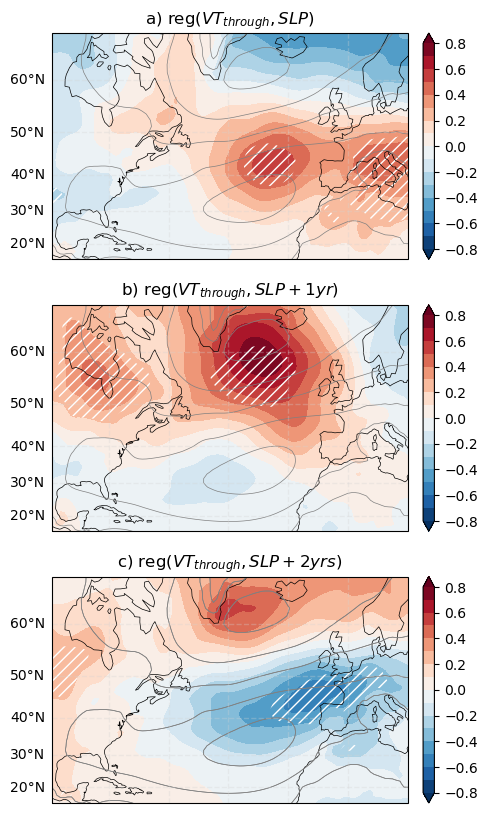

In [6]:
# Plotting Fig. 5
data_proj = crs.PlateCarree()
display_proj = crs.Mercator() 

slp_clim = slp_an.mean(dim='time', skipna=True) #time mean slp
slp_clim, clon = add_cyclic_point(slp_clim, coord=lon)

fig, ax = plt.subplots(3,figsize=(10, 10),subplot_kw={'projection': display_proj})
plt.rcParams.update({'hatch.color': 'white'})

ax[0].set_extent([-99,20,15,67],crs=data_proj)
ax[0].coastlines(linewidths=0.5)
g=ax[0].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
ax[0].set_title('a) reg($VT_{through},SLP$)')
#
ctrs1=ax[0].contourf(clon,lat,REGspg[:,:,0], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.8,0.8,17), extend='both') 
cbar1 = plt.colorbar(ctrs1,ax=ax[0],label='',pad=0.02, shrink=1) #shift colorbar with pad
# significance
hatch1=ax[0].contourf(clon,lat,PVALspg[:,:,0], transform = data_proj,levels=[0,0.1],hatches=['///',None],colors='none')
#
ctrs=ax[0].contour(clon,lat,slp_clim/100, transform = data_proj,levels=[1005,1009,1013,1017,1021],colors='grey',linewidths=0.5) 


ax[1].set_extent([-99,20,15,67],crs=data_proj)
ax[1].coastlines(linewidths=0.5)
g=ax[1].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
ax[1].set_title('b) reg($VT_{through},SLP + 1 yr$)')
#
ctrs2=ax[1].contourf(clon,lat,REGspg[:,:,1], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.8,0.8,17), extend='both') 
cbar2 = plt.colorbar(ctrs2,ax=ax[1],label='',pad=0.02,shrink=1) #shift colorbar with pad
# significance
hatch2=ax[1].contourf(clon,lat,PVALspg[:,:,1], transform = data_proj,levels=[0,0.1],hatches=['///',None],colors='none')
#
ctrs=ax[1].contour(clon,lat,slp_clim/100, transform = data_proj,levels=[1005,1009,1013,1017,1021],colors='grey',linewidths=0.5) 


ax[2].set_extent([-99,20,15,67],crs=data_proj)
ax[2].coastlines(linewidths=0.5)
g=ax[2].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
ax[2].set_title('c) reg($VT_{through},SLP + 2 yrs$)')
#
ctrs3=ax[2].contourf(clon,lat,REGspg[:,:,2], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.8,0.8,17), extend='both') 
cbar3 = plt.colorbar(ctrs3,ax=ax[2],label='',pad=0.02, shrink=1) #shift colorbar with pad
ctrs=ax[2].contour(clon,lat,slp_clim/100, transform = data_proj,levels=[1005,1009,1013,1017,1021],colors='grey',linewidths=0.5) 
# significance
hatch3=ax[2].contourf(clon,lat,PVALspg[:,:,2], transform = data_proj,levels=[0,0.1],hatches=['///',None],colors='none')
#
ctrs=ax[2].contour(clon,lat,slp_clim/100, transform = data_proj,levels=[1005,1009,1013,1017,1021],colors='grey',linewidths=0.5) 
